In [2]:
import requests

In [3]:
import pandas as pd

In [4]:
url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream"

In [5]:
params = {
    "settlementDateFrom": "2024-01-01",
    "settlementDateTo": "2024-01-31",
    "fuelType": "WIND",
    "format": "json"
}

In [6]:
response = requests.get(url, params=params)
data = response.json()

In [7]:
df_actual = pd.DataFrame(data)

In [8]:
df_actual

,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,FUELHH,2024-02-01T00:00:00Z,2024-01-31T23:30:00Z,2024-01-31,48,WIND,14355
1,FUELHH,2024-01-31T23:30:00Z,2024-01-31T23:00:00Z,2024-01-31,47,WIND,14595
2,FUELHH,2024-01-31T23:00:00Z,2024-01-31T22:30:00Z,2024-01-31,46,WIND,14908
3,FUELHH,2024-01-31T22:30:00Z,2024-01-31T22:00:00Z,2024-01-31,45,WIND,15490
4,FUELHH,2024-01-31T22:00:00Z,2024-01-31T21:30:00Z,2024-01-31,44,WIND,15719
...,...,...,...,...,...,...,...
1483,FUELHH,2024-01-01T02:30:00Z,2024-01-01T02:00:00Z,2024-01-01,5,WIND,11234
1484,FUELHH,2024-01-01T02:00:00Z,2024-01-01T01:30:00Z,2024-01-01,4,WIND,11223
1485,FUELHH,2024-01-01T01:30:00Z,2024-01-01T01:00:00Z,2024-01-01,3,WIND,11218
1486,FUELHH,2024-01-01T01:00:00Z,2024-01-01T00:30:00Z,2024-01-01,2,WIND,10845


In [10]:
print(df_actual.describe())

       settlementPeriod    generation
count       1488.000000   1488.000000
mean          24.500000   9848.730511
std           13.858056   3676.018748
min            1.000000      0.000000
25%           12.750000   6732.500000
50%           24.500000   9863.500000
75%           36.250000  13105.250000
max           48.000000  16662.000000


In [15]:
import matplotlib.pyplot as plt

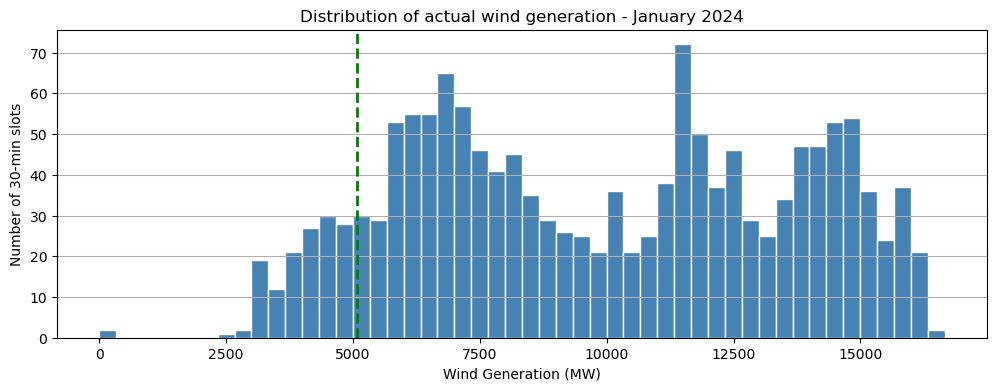

In [27]:
df_actual['generation'].plot(kind='hist', bins=50, figsize=(12,4), 
                          color='steelblue', edgecolor='white')
plt.axvline(p10, color='green', linestyle='--', linewidth=2, label=f'90% reliable → {p10:.0f} MW')
plt.xlabel('Wind Generation (MW)')
plt.ylabel('Number of 30-min slots')
plt.title('Distribution of actual wind generation - January 2024')
plt.grid(True, axis='y')
plt.show()

In [20]:
p25 = df_actual['generation'].quantile(0.25)
p10 = df_actual['generation'].quantile(0.10)
p50 = df_actual['generation'].quantile(0.50)

In [21]:
print(p25)

6732.5


In [22]:
print(p10)

5087.900000000001


In [23]:
print(p50)

9863.5


In [ ]:
Recommendation: 5,087 MW
Based on January 2024 actual wind generation data, UK wind power exceeded 5,087 MW in 90% of all 30-minute slots. This is the recommended reliable baseline for grid planning purposes.
While average generation was ~9,848 MW, relying on the mean would result in shortfalls 50% of the time. The 10th percentile (5,087 MW) provides a conservative, safe estimate that grid operators can depend on with 90% confidence.
Wind generation ranged from 0 MW (calm periods) to 16,662 MW (peak conditions), highlighting the variable nature of wind power and the importance of using percentile-based reliability estimates rather than averages.